In [1]:
import pandas as pd

skiver_calibration_df = pd.read_csv("../../output/zymo/skiver/ERR3152366.summary_phred.csv")
skiver_calibration_df.head()

,qscore,empirical_qscore,num_correct,num_error,error_rate
0,1,4.4730,1972,1095,0.357026
1,2,4.1079,29896,18981,0.388342
2,3,4.8789,126106,60765,0.325171
3,4,5.9316,163989,56182,0.255174
4,5,7.1041,173293,41924,0.194799


In [2]:
minimap_calibration_df = pd.read_csv("../../output/zymo/ERR3152366.summary_qual_score_stats.csv")
minimap_calibration_df["empirical_error_rate"] = 1 - minimap_calibration_df["matches"] / (minimap_calibration_df["matches"] + \
                                                                                          minimap_calibration_df["mismatches"] + \
                                                                                          minimap_calibration_df["insertions"] + minimap_calibration_df["deletions"])
                                                                                          
minimap_calibration_df.head()

,feature,qual_score,matches,mismatches,insertions,deletions,clipped,skipped,empirical_qv,empirical_error_rate
0,all_alignments,1,12351381,3525813,3012200,2651552,5731814,0,6.54,0.426609
1,all_alignments,2,147173589,54159394,34402967,34449457,49083054,0,5.70,0.455287
2,all_alignments,3,418037126,129046467,73674597,81020784,90434638,0,6.27,0.404318
3,all_alignments,4,473086301,107039775,62917020,78201815,78833950,0,7.34,0.344070
4,all_alignments,5,445380641,74002532,44808547,63168697,60097888,0,8.46,0.290072


In [3]:
seqtk_df = pd.read_csv("../../output/qc_by_quality_score/zymo_ERR3152366_seqtk.fqchk.txt", sep="\t", skiprows=1)
def seqtk_df_to_calibration_df(seqtk_df):
    # in columns, turn %Q1, %Q2, ... into quality score
    quality_scores = []
    for col in seqtk_df.columns:
        if col.startswith("%Q"):
            quality_score = int(col[2:])
            quality_scores.append(quality_score)
    
    percentages = []
    for quality_score in quality_scores:
        percentage_col = f"%Q{quality_score}"
        percentages.append(seqtk_df[percentage_col].values[0])
    
    calibration_df = pd.DataFrame({
        "quality_score": quality_scores,
        "percentage": percentages
    })
    return calibration_df
seqtk_calibration_df = seqtk_df_to_calibration_df(seqtk_df)
seqtk_calibration_df.head()

/tmp/ipykernel_8446/4227317209.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  seqtk_df = pd.read_csv("../../output/qc_by_quality_score/zymo_ERR3152366_seqtk.fqchk.txt", sep="\t", skiprows=1)


,quality_score,percentage
0,1,0.21
1,2,2.31
2,3,5.35
3,4,5.23
4,5,4.37


In [4]:
# join the two dataframes on the "qscore" column for skiver and "qual_score" column for minimap

joined_df = pd.merge(
    skiver_calibration_df,
    minimap_calibration_df,
    left_on="qscore",
    right_on="qual_score",
    how="inner",
)
#joined_df["minimap_empirical_error_rate"] = 10 **(-joined_df["empirical_qv"] / 10)


In [5]:
joined_df.head()

,qscore,empirical_qscore,num_correct,num_error,error_rate,feature,qual_score,matches,mismatches,insertions,deletions,clipped,skipped,empirical_qv,empirical_error_rate
0,1,4.4730,1972,1095,0.357026,all_alignments,1,12351381,3525813,3012200,2651552,5731814,0,6.54,0.426609
1,2,4.1079,29896,18981,0.388342,all_alignments,2,147173589,54159394,34402967,34449457,49083054,0,5.70,0.455287
2,3,4.8789,126106,60765,0.325171,all_alignments,3,418037126,129046467,73674597,81020784,90434638,0,6.27,0.404318
3,4,5.9316,163989,56182,0.255174,all_alignments,4,473086301,107039775,62917020,78201815,78833950,0,7.34,0.344070
4,5,7.1041,173293,41924,0.194799,all_alignments,5,445380641,74002532,44808547,63168697,60097888,0,8.46,0.290072


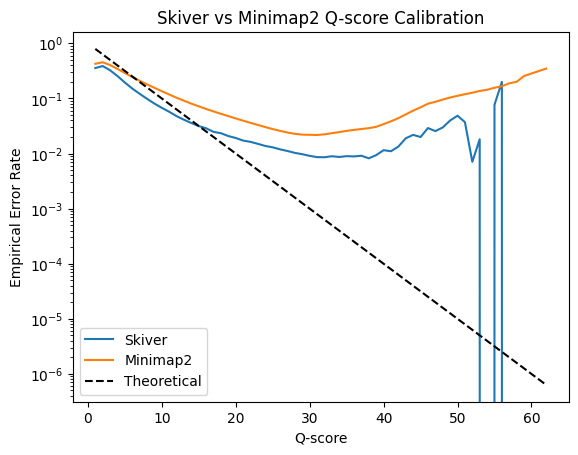

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.plot(joined_df["qscore"], joined_df["error_rate"], label="Skiver")
plt.plot(joined_df["qscore"], joined_df["empirical_error_rate"], label="Minimap2")
plt.plot(joined_df["qscore"], 10 ** (-joined_df["qscore"]/10), label="Theoretical", color='black', linestyle='dashed')
plt.xlabel("Q-score")
plt.ylabel("Empirical Error Rate")
plt.title("Skiver vs Minimap2 Q-score Calibration")
plt.yscale("log")
plt.legend()

In [7]:
# Sanity check

#minimap2 total empirical error rate
joined_df["num_total"] = seqtk_calibration_df["percentage"] #joined_df["num_error"] + joined_df["num_correct"]
(joined_df["empirical_error_rate"] * seqtk_calibration_df["percentage"]).sum() / seqtk_calibration_df["percentage"].sum()

0.12535024124017363

In [8]:
#joined_df["num_total"] = joined_df["num_error"] + joined_df["num_correct"]
(joined_df["error_rate"] * seqtk_calibration_df["percentage"]).sum() / seqtk_calibration_df["percentage"].sum()

0.08010594829482949

In [9]:
joined_df["num_total"] = joined_df["num_error"] + joined_df["num_correct"]
joined_df["skiver_percentage"] = joined_df["num_total"] / joined_df["num_total"].sum() * 100

In [10]:
seqtk_calibration_df

,quality_score,percentage
0,1,0.21
1,2,2.31
2,3,5.35
3,4,5.23
4,5,4.37
...,...,...
56,57,0.00
57,58,0.00
58,59,0.00
59,62,0.00


Text(0.5, 1.0, 'Phred score distribution of Zymo log, Nanopore GridION')

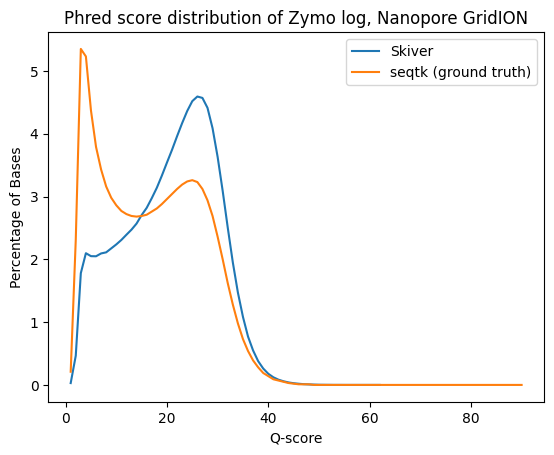

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.plot(joined_df["qscore"], joined_df["skiver_percentage"], label="Skiver")
plt.plot(seqtk_calibration_df["quality_score"], seqtk_calibration_df["percentage"], label="seqtk (ground truth)")
plt.xlabel("Q-score")
plt.ylabel("Percentage of Bases")
plt.legend()
plt.title("Phred score distribution of Zymo log, Nanopore GridION")

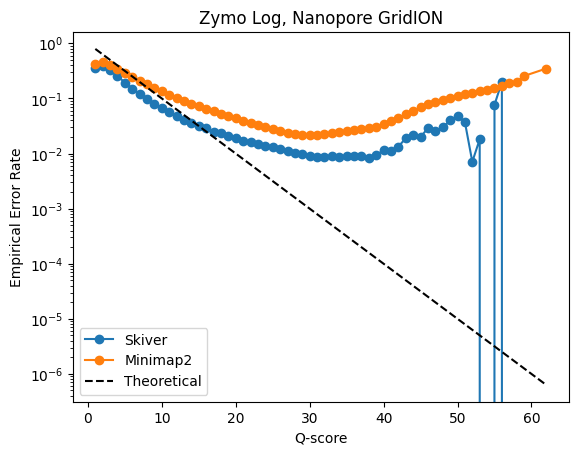

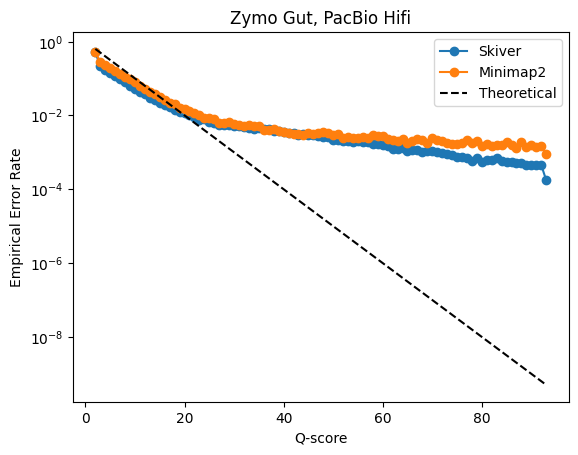

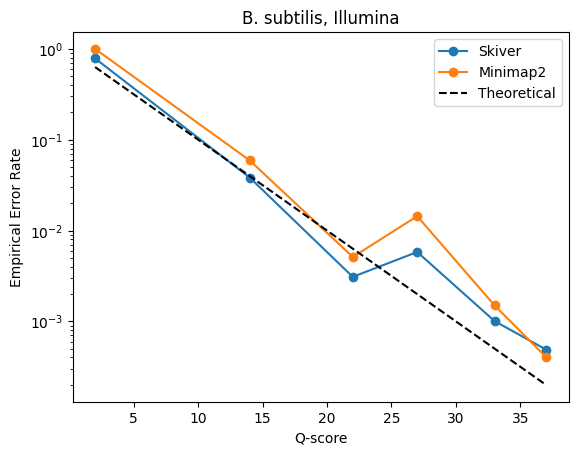

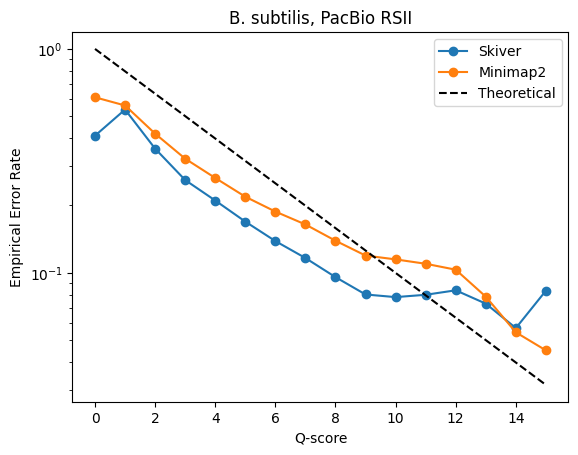

In [14]:
skiver_calibration = [
    "../../output/zymo/skiver/ERR3152366.summary_phred.csv",
    "../../output/zymo/skiver/SRR13128014.summary_phred.csv",
    "../../output/zymo/skiver/ERR2935851.summary_phred.csv",
    "../../output/zymo/skiver/SRR7498042.summary_phred.csv"
]

minimap_calibration = [
    "../../output/zymo/ERR3152366.summary_qual_score_stats.csv",
    "../../output/zymo/SRR13128014.summary_qual_score_stats.csv",
    "../../output/zymo/ERR2935851_assembly.summary_qual_score_stats.csv",
    "../../output/zymo/SRR7498042_assembly.summary_qual_score_stats.csv"
]

dataset_names = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut, PacBio Hifi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII"
]

for skiver_file, minimap_file, name in zip(skiver_calibration, minimap_calibration, dataset_names):
    skiver_calibration_df = pd.read_csv(skiver_file)
    minimap_calibration_df = pd.read_csv(minimap_file)
    minimap_calibration_df["empirical_error_rate"] = 1 - minimap_calibration_df["matches"] / (minimap_calibration_df["matches"] + \
                                                                                              minimap_calibration_df["mismatches"] + \
                                                                                              minimap_calibration_df["insertions"] + minimap_calibration_df["deletions"])
    joined_df = pd.merge(
        skiver_calibration_df,
        minimap_calibration_df,
        left_on="qscore",
        right_on="qual_score",
        how="inner",
    )
    plt.Figure(figsize=(10, 6))
    plt.plot(joined_df["qscore"], joined_df["error_rate"], marker='o', label=f"Skiver")
    plt.plot(joined_df["qscore"], joined_df["empirical_error_rate"], marker='o', label=f"Minimap2")
    plt.plot(joined_df["qscore"], 10 ** (-joined_df["qscore"]/10), label="Theoretical", color='black', linestyle='dashed')
    plt.xlabel("Q-score")
    plt.ylabel("Empirical Error Rate")
    plt.title(name)
    plt.yscale("log")
    plt.legend()
    plt.show()


In [3]:
import pandas as pd


skiver_qc_df = pd.read_csv("../../output/zymo/skiver/ERR3152366.qc.csv")
minimap_aln_df = pd.read_csv("../../output/zymo/ERR3152366.per_aln_stats.csv")

skiver_qc_df.head()

,read_name,error_rate_reported,error_rate_calibrated
0,ERR3152366.1 18a63e57-67ba-4e58-89b2-9decf434a...,0.331810,0.209974
1,ERR3152366.2 627b76b8-db93-4cb2-911a-d1128251a...,0.283142,0.180170
2,ERR3152366.3 901a191c-0b56-4f4b-8ed0-f52c2db02...,0.233706,0.150386
3,ERR3152366.4 a9171295-a705-4dc3-a5a7-851938c4e...,0.185634,0.121425
4,ERR3152366.5 59acede8-de45-4666-b679-2812bd38c...,0.190831,0.124385


In [24]:
minimap_aln_df.iloc[0]

read                                     ERR3152366.1317769
chr                           BS.pilon.polished.v3.ST170922
pos                                                       1
read_length                                             713
effective_coverage                                      NaN
subread_passes                                          NaN
predicted_concordance                                   NaN
alignment_type                                supplementary
strand                                                    +
alignment_mapq                                           60
mean_quality                                             11
aligned_read_length                                     727
reference_coverage                                  0.00018
gc_content                                         0.455296
concordance                                        0.919728
gap_compressed_concordance                         0.929849
concordance_qv                          

In [27]:
1 - (29+3+5) / 713

0.9481065918653576

In [4]:
read_name_clean = []
for i in range(len(skiver_qc_df)):
    read_name_clean.append(skiver_qc_df["read_name"][i].split(" ")[0])

skiver_qc_df["read_name_clean"] = read_name_clean

In [5]:
# join the two dataframes on the "read_name_clean" column for skiver and "read" column for minimap

joined_df = pd.merge(
    skiver_qc_df,
    minimap_aln_df,
    left_on="read_name_clean",
    right_on="read",
    how="inner",
)


In [28]:
joined_df.iloc[0]

read_name                     ERR3152366.1 18a63e57-67ba-4e58-89b2-9decf434a...
error_rate_reported                                                     0.33181
error_rate_calibrated                                                  0.209974
read_name_clean                                                    ERR3152366.1
read                                                               ERR3152366.1
chr                                      Pseudomonas_aeruginosa_complete_genome
pos                                                                     2294656
read_length                                                                9966
effective_coverage                                                          NaN
subread_passes                                                              NaN
predicted_concordance                                                       NaN
alignment_type                                                          primary
strand                                  

In [7]:
joined_df["match_rate"] = 1 - (joined_df["mismatches"] + joined_df["non_hp_ins"] + joined_df["hp_ins"]) / joined_df["read_length"]

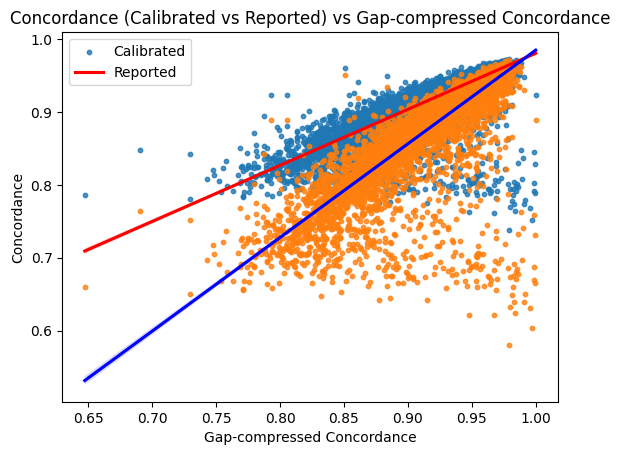

Linear Regression (Reported): R^2=0.8873, Slope=0.9385, Intercept=0.0666
Pearson Correlation (Reported): r=0.8291, p=0.0000e+00
Spearman Correlation (Reported): r=0.8948, p=0.0000e+00
Pearson Correlation: r=0.8287, p=0.0000e+00
Spearman Correlation: r=0.8947, p=0.0000e+00


In [10]:
# Plot gap_compressed_concordance vs error_rate_calibrated
# Perform a linear regression and report R^2, slope, and intercept, and plot the regression line
# Report the pearson and spearman correlation
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr, spearmanr


joined_df["concordance_calibrated"] = 1 - joined_df["error_rate_calibrated"]
joined_df["concordance_reported"] = 1 - joined_df["error_rate_reported"]
joined_df_sub = joined_df.iloc[1:10000] # take a subset of the data for plotting
sns.regplot(x="match_rate", y="concordance_calibrated", data=joined_df_sub, scatter_kws={"s": 10}, line_kws={"color": "red"}, label="Calibrated")
sns.regplot(x="match_rate", y="concordance_reported", data=joined_df_sub, scatter_kws={"s": 10}, line_kws={"color": "blue"}, label="Reported")
plt.xlabel("Gap-compressed Concordance")
plt.ylabel("Concordance")
plt.title("Concordance (Calibrated vs Reported) vs Gap-compressed Concordance")
plt.legend(["Calibrated", "Reported"])
plt.show()

target = joined_df_sub["match_rate"]

# Perform linear regression for reported concordance
slope_reported, intercept_reported, r_value_reported, p_value_reported, std_err_reported = linregress(
    joined_df_sub["concordance"], joined_df_sub["concordance_reported"]
)
print(f"Linear Regression (Reported): R^2={r_value_reported**2:.4f}, Slope={slope_reported:.4f}, Intercept={intercept_reported:.4f}")

# Calculate Pearson and Spearman correlation for reported concordance
pearson_corr_reported, pearson_p_reported = pearsonr(
    target, joined_df_sub["concordance_reported"]
)
spearman_corr_reported, spearman_p_reported = spearmanr(
    target, joined_df_sub["concordance_reported"]
)
print(f"Pearson Correlation (Reported): r={pearson_corr_reported:.4f}, p={pearson_p_reported:.4e}")
print(f"Spearman Correlation (Reported): r={spearman_corr_reported:.4f}, p={spearman_p_reported:.4e}")

# Calculate Pearson and Spearman correlation
pearson_corr, pearson_p = pearsonr(target, joined_df_sub["concordance_calibrated"])
spearman_corr, spearman_p = spearmanr(target, joined_df_sub["concordance_calibrated"])
print(f"Pearson Correlation: r={pearson_corr:.4f}, p={pearson_p:.4e}")
print(f"Spearman Correlation: r={spearman_corr:.4f}, p={spearman_p:.4e}")



In [19]:
joined_df_sub

,read_name,error_rate_reported,error_rate_calibrated,read_name_clean,read,chr,pos,read_length,effective_coverage,subread_passes,...,gc_content,concordance,gap_compressed_concordance,concordance_qv,mismatches,non_hp_ins,non_hp_del,hp_ins,hp_del,concordance_calibrated
1,ERR3152366.2 627b76b8-db93-4cb2-911a-d1128251a...,0.283142,0.180170,ERR3152366.2,ERR3152366.2,Listeria_monocytogenes_complete_genome,944352,5974,NaN,NaN,...,0.386297,0.718714,0.777640,5.51,571,332,242,92,233,0.819830
2,ERR3152366.3 901a191c-0b56-4f4b-8ed0-f52c2db02...,0.233706,0.150386,ERR3152366.3,ERR3152366.3,Listeria_monocytogenes_complete_genome,2205380,6231,NaN,NaN,...,0.353345,0.750344,0.811858,6.03,565,324,302,96,344,0.849614
3,ERR3152366.4 a9171295-a705-4dc3-a5a7-851938c4e...,0.185634,0.121425,ERR3152366.4,ERR3152366.4,Listeria_monocytogenes_complete_genome,920659,2948,NaN,NaN,...,0.346652,0.775090,0.828442,6.48,247,225,69,56,91,0.878575
4,ERR3152366.5 59acede8-de45-4666-b679-2812bd38c...,0.190831,0.124385,ERR3152366.5,ERR3152366.5,Listeria_monocytogenes_complete_genome,2363805,3717,NaN,NaN,...,0.357237,0.785447,0.832321,6.68,317,150,159,56,179,0.875615
5,ERR3152366.6 34947bc8-7f78-4bf8-8655-d3869cb33...,0.214110,0.138779,ERR3152366.6,ERR3152366.6,Listeria_monocytogenes_complete_genome,1950159,4200,NaN,NaN,...,0.388155,0.752525,0.806733,6.06,409,262,175,54,227,0.861221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ERR3152366.10328 4ff1f0b6-dcbc-4521-8f43-dc9de...,0.083863,0.060720,ERR3152366.10328,ERR3152366.10328,Listeria_monocytogenes_complete_genome,1527342,2321,NaN,NaN,...,0.372003,0.907686,0.925863,10.35,90,37,28,21,45,0.939280
9996,ERR3152366.10329 9d691a61-1fc9-4c35-819d-2676b...,0.053902,0.042689,ERR3152366.10329,ERR3152366.10329,Listeria_monocytogenes_complete_genome,399370,6410,NaN,NaN,...,0.409353,0.945340,0.955611,12.62,108,47,58,51,92,0.957311
9997,ERR3152366.10330 d7cd48ad-89ac-41da-b1a6-1b527...,0.238647,0.152887,ERR3152366.10330,ERR3152366.10330,Listeria_monocytogenes_complete_genome,2638054,4609,NaN,NaN,...,0.381039,0.777080,0.818351,6.52,474,108,215,41,298,0.847113
9998,ERR3152366.10331 a0e57828-731b-46c7-9b99-4f602...,0.070170,0.052448,ERR3152366.10331,ERR3152366.10331,Listeria_monocytogenes_complete_genome,234410,3733,NaN,NaN,...,0.379301,0.923360,0.937383,11.16,107,40,51,21,73,0.947552


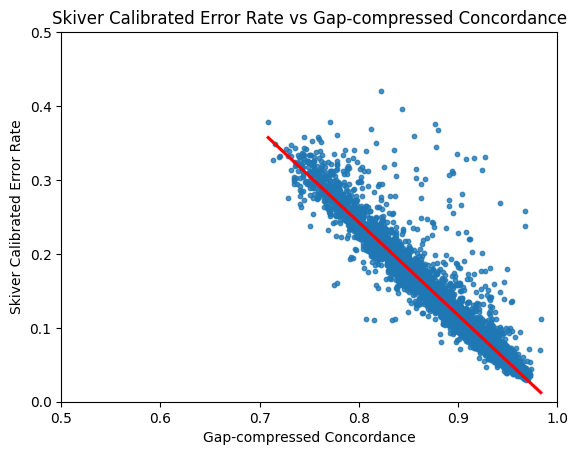

Linear Regression: R^2=0.9262, Slope=-1.2553, Intercept=1.2468
Pearson Correlation: r=-0.9624, p=0.0000e+00
Spearman Correlation: r=-0.9706, p=0.0000e+00


In [15]:
# Plot gap_compressed_concordance vs error_rate_calibrated
# Perform a linear regression and report R^2, slope, and intercept, and plot the regression line
# Report the pearson and spearman correlation
import seaborn as sns
import matplotlib.pyplot as plt

joined_df_sub = joined_df.iloc[1:10000] # take a subset of the data for plotting

sns.regplot(x="gap_compressed_concordance", y="error_rate_reported", data=joined_df_sub, scatter_kws={"s": 10}, line_kws={"color": "red"})
plt.xlabel("Gap-compressed Concordance")
plt.ylabel("Skiver Calibrated Error Rate")
plt.title("Skiver Calibrated Error Rate vs Gap-compressed Concordance")
plt.xlim(0.5, 1)
plt.ylim(0, 0.5)
plt.show()

from scipy.stats import linregress, pearsonr, spearmanr

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(joined_df_sub["gap_compressed_concordance"], joined_df_sub["error_rate_reported"])
print(f"Linear Regression: R^2={r_value**2:.4f}, Slope={slope:.4f}, Intercept={intercept:.4f}")

# Calculate Pearson and Spearman correlation
pearson_corr, pearson_p = pearsonr(joined_df_sub["gap_compressed_concordance"], joined_df_sub["error_rate_reported"])
spearman_corr, spearman_p = spearmanr(joined_df_sub["gap_compressed_concordance"], joined_df_sub["error_rate_reported"])
print(f"Pearson Correlation: r={pearson_corr:.4f}, p={pearson_p:.4e}")
print(f"Spearman Correlation: r={spearman_corr:.4f}, p={spearman_p:.4e}")



In [4]:
skiver_qc_df['error_rate_calibrated'].mean()

0.08401195714196119

In [3]:
minimap_aln_df.head()

,read,chr,pos,read_length,effective_coverage,subread_passes,predicted_concordance,alignment_type,strand,alignment_mapq,...,reference_coverage,gc_content,concordance,gap_compressed_concordance,concordance_qv,mismatches,non_hp_ins,non_hp_del,hp_ins,hp_del
0,ERR3152366.1317769,BS.pilon.polished.v3.ST170922,1,713,NaN,NaN,NaN,supplementary,+,60,...,0.000180,0.455296,0.919728,0.929849,10.95,29,3,10,5,12
1,ERR3152366.1773054,BS.pilon.polished.v3.ST170922,1,1810,NaN,NaN,NaN,supplementary,+,60,...,0.000455,0.412500,0.930096,0.947798,11.55,33,21,32,13,32
2,ERR3152366.730384,BS.pilon.polished.v3.ST170922,1,379,NaN,NaN,NaN,supplementary,-,60,...,0.000093,0.436508,0.910486,0.927083,10.48,10,10,7,3,5
3,ERR3152366.150570,BS.pilon.polished.v3.ST170922,1,795,NaN,NaN,NaN,supplementary,-,60,...,0.000199,0.435323,0.855263,0.881628,8.39,48,19,19,13,22
4,ERR3152366.2119173,BS.pilon.polished.v3.ST170922,1,5225,NaN,NaN,NaN,primary,+,60,...,0.000655,0.430026,0.911959,0.930389,10.55,82,52,30,23,53
